# Lab 5: Análisis Estadístico de Trenes de Spike

## Introducción

Las neuronas de la retina suelen responder a patrones de luz que se muestran en pequeñas secciones del campo visual. Sin embargo, cuando las neuronas de la retina se cultivan y se mantienen bajo condiciones ambientales y de luz constantes, seguirán disparando espontáneamente potenciales de acción. En una retina en pleno funcionamiento, esta actividad espontánea a veces se describe como actividad de fondo, que se modula en función de los estímulos visuales. Es útil comprender las propiedades de esta actividad de fondo para determinar en experimentos futuros cómo estas propiedades de activación se ven afectadas por estímulos específicos.

## Caso de Estudio

Una investigadora que examina las propiedades de actividad de fondo de una de estas neuronas se comunica con usted para discutir sus datos. Su colaboradora ha registrado los potenciales de acción en dos condiciones experimentales: con las luces de la habitación apagadas (niveles bajos de luz ambiental) o con las luces encendidas (niveles altos de luz ambiental). A ella le gustaría colaborar con usted para determinar si existe una diferencia en el disparo de fondo entre estas dos condiciones. El registro de actividad neuronala se ha hecho durante 30 segundos en cada condición.

## Ejercicio 1

Cargue los datos en python para su procesamiento. Para ello use el módulo scipy.io la función loadmat.

Debería encontrar dos variables en el diccionario de datos:

*SpikesLow*: tiempos de disparo durante 30 s en condiciones de poca luz,

*SpikesHigh*: tiempos de disparo durante 30 s en condiciones de luz alta.

**Q:** Cuál es el firing rate promedio en de la neurona en condiciones de luz baja y de luz ambiental?

In [7]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

data = scipy.io.loadmat('08_spikes-1.mat')

# SpikesLow:
SpikeLow = data['SpikesLow']
# SpikesHigh:
SpikeHigh = data['SpikesHigh']

ISI_SpikeLow = np.mean(np.diff(SpikeLow)) #ISI promedio

ISI_SpikeHigh = np.mean(np.diff(SpikeHigh)) #ISI promedio

Firing_Rate_Low = 1/ISI_SpikeLow #Firing rate promedio

Firing_Rate_High = 1/ISI_SpikeHigh #Firing rate promedio

print(f"Luz baja - Firing rate promedio {Firing_Rate_Low}")
print(f"Luz ambiental - Firing rate promedio {Firing_Rate_High}")



Luz baja - Firing rate promedio 25.007253801355365
Luz ambiental - Firing rate promedio 32.31855759655577


## Ejercicio 2

Habrá notado que en nuestro experimento se nos da simplemente los tiempos de disparo. Para visualizar los tiempos de disparo se suele representar a través de un raster-plot. En este se muestra en el eje horizontal los tiempos de disparo y en el eje vertical se grafica el índice de la neurona que emitió dicho disparo. En este experimeto tenemos solo una neurona pero bajo dos experimentos distintos así que pues al eje vertical se le puede asignar el índice 1 (para el experimento de poca luz) y 2 (para el de luz alta)

Haga el raster plot para las dos condiciones experimentales.

**Q** Encuentra alguna diferencia cualitativa entre el disparo de la neurona en ambas condiciones experimentales?

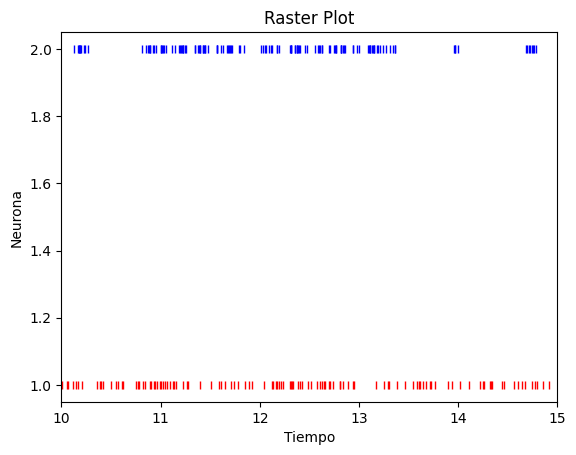

In [8]:
plt.plot(SpikeLow,[1]*np.shape(SpikeLow)[0],"r|")
plt.plot(SpikeHigh,[2]*np.shape(SpikeHigh)[0],"b|")
plt.xlabel("Tiempo")
plt.ylabel("Neurona")
plt.title("Raster Plot")
plt.xlim([10,15])
plt.show()

En poca luz los disparos son más uniformes y constantes mientras que en un ambiente más iluminado los spikes son más rápidos pero por intervalos de tiempo.

## Ejercicio 3

Compute la distribución de los ISI para ambos experimentos. Esto le debe permitir determinar con más claridad las diferencias entre la estadística de disparo de la neurona en ambos experimentos.

**Q** Describa las características de los dos histogramas. ¿Qué características de las distribuciones ISI son similares para las dos condiciones? ¿Qué características son diferentes?

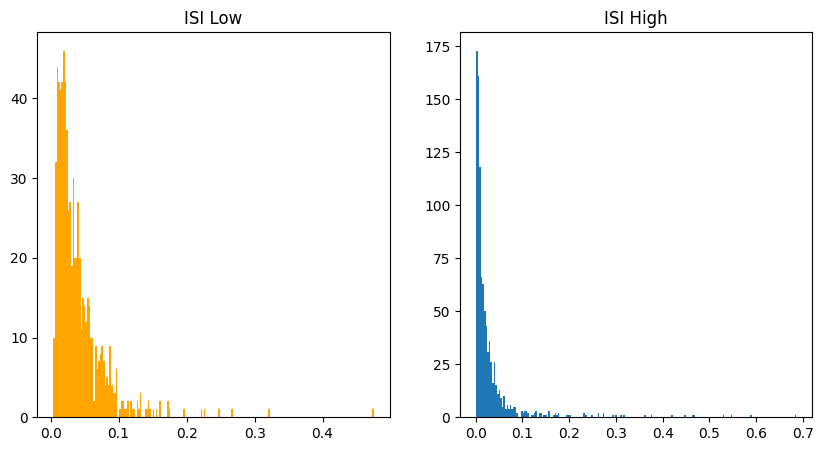

In [9]:
data = scipy.io.loadmat('08_spikes-1.mat')

# SpikesLow:
SpikeLow = data['SpikesLow']
# SpikesHigh:
SpikeHigh = data['SpikesHigh']

ISI_Low = np.diff(SpikeLow[0])
ISI_High = np.diff(SpikeHigh[0])

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.hist(ISI_Low,bins=200,color="orange")
plt.title("ISI Low")

plt.subplot(1,2,2)
plt.hist(ISI_High,bins=200)
plt.title("ISI High")
plt.show()

Ambas distribuciones se aproximan a una gamma, además tanto el ISI Low como el ISI High tienen valores predominantemente bajos, indicando que la mayoría de los disparos neuronales ocurren con intervalos cortos.

Las distribuciones de ISI Low e ISI High presentan diferencias claras en su rango y dispersión. El rango del ISI Low es más estrecho, mientras que el ISI High se extiende más. Además, el histograma de ISI High muestra una mayor cantidad de valores en el intervalo inicial.
En el ISI Low se presenta una distribución más concentrada en los valores bajos. El ISI High es más disperso, mostrando más eventos en ISIs mayores.

## Ejercicio 4:

Una forma común de determinar la variabilidad en el disparo de una neurona es através del coeficiente de variación del ISI definido como

$$
CV(ISI) = \frac{\sigma(ISI)}{\mu(ISI)}
$$

Una regla general para interpretar el CV es el siguiente

* $CV \approx 0$, el disparo es regular -Disparo Tónico-
* $CV \approx 1$, el disparo es irregular, parece completamente aleatorio -Proceso de Poisson-
* $CV > 1$, el disparo es de tipo Bursting, la neurona emite "ráfagas" de spikes en un periodo corto, y se queda sin disparar durante un periodo largo

Calcule el CV para los dos experimentos

**Q** Qué tipo de disparo hay en cada uno de los dos experimentos?

In [10]:
CV=(np.std(ISI_Low)/np.mean(ISI_Low))
print(f"CV Low {CV}")
CV=(np.std(ISI_High)/np.mean(ISI_High))
print(f"CV High {CV}")

CV Low 0.9642104029667415
CV High 2.0217913245616757


En el experimento a poca luz (low) como el CV se aproxima a 1, entonces el disparo es irregular, parece completamente aleatorio -Proceso de Poisson-. Ahora, el experimento con exposición a luz (high),  el disparo es de tipo Bursting, la neurona emite "ráfagas" de spikes en un periodo corto, y se queda sin disparar durante un periodo largo, esto pues su CV es notoriamente mayor que 1.

## Ejercicio 5

Otro enfoque común para analizar datos de picos es discretizar el tiempo en intervalos de ancho fijo y contar el número de eventos -spikes- que ocurren en cada intervalo de tiempo. La secuencia de conteo de picos en todos los intervalos a veces se denomina proceso de incremento del tren de spikes. Cuando los intervalos de tiempo son lo suficientemente pequeños, digamos 1 ms, el proceso de incremento resultante es solo una secuencia de ceros y unos.

Cuente los eventos que hay en cada intervalos de 50ms para los dos experimentos.

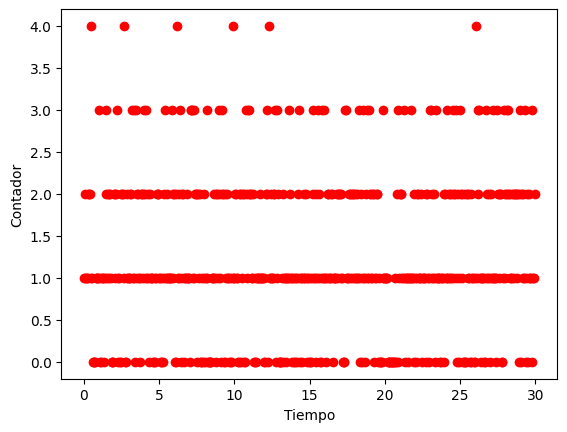

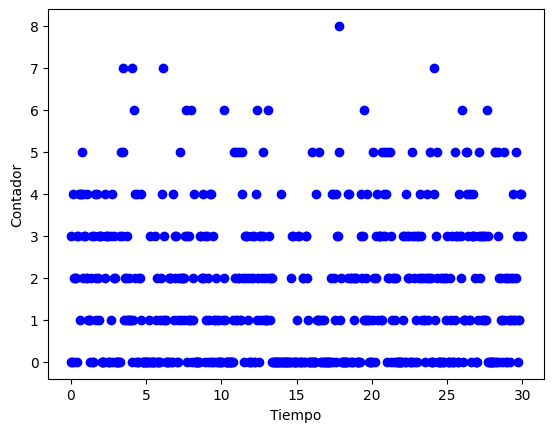

In [11]:
SpikeLow = data['SpikesLow'][0]
SpikeHigh = data['SpikesHigh'][0]
tiempo = np.arange(0,30,0.05)
contador_Low = np.array([])
contador_High = np.array([])

for tiempo_ini in tiempo:
  tiempo_fin = tiempo_ini + 0.05
  num_spikes_Low = SpikeLow[(SpikeLow>tiempo_ini) & (tiempo_fin>SpikeLow)]
  num_spikes_High = SpikeHigh[(SpikeHigh>tiempo_ini) & (tiempo_fin>SpikeHigh)]
  contador_Low = np.append(contador_Low,len(num_spikes_Low))
  contador_High = np.append(contador_High,len(num_spikes_High))

plt.plot(tiempo,contador_Low,"ro")
plt.xlabel("Tiempo")
plt.ylabel("Contador")
plt.show()

plt.plot(tiempo,contador_High,"bo")
plt.xlabel("Tiempo")
plt.ylabel("Contador")
plt.show()

Otra medida de variabilidad de disparo se puede calcular con el proceso de incremento usando el factor de Fano muestral (FF). Es fácil definir el factor de Fano: FF es la varianza muestral del proceso incremental dividida por la media muestral del proceso incremental.

$$
FF = Var(X)/\mu(X)
$$

Al igual que con el CV, el Factor de Fano tiene interpretaciones similares

* $FF \approx 0$, el disparo es regular -Disparo Tónico-
* $FF \approx 1$, el disparo es irregular, parece completamente aleatorio -Proceso de Poisson-
* $FF > 1$, el disparo es de tipo Bursting, la neurona emite "ráfagas" de spikes en un periodo corto, y se queda sin disparar durante un periodo largo

**Q** Calucle el factor de Fano para el proceso de incremento calculado en ambas condiciones


In [12]:
Var_Low = np.var(contador_Low)
Var_High = np.var(contador_High)
media_Low = np.mean(contador_Low)
media_High = np.mean(contador_High)
FF_Low = Var_Low/media_Low
FF_High = Var_High/media_High
print(f"FF Low {FF_Low}")
print(f"FF High {FF_High}")

FF Low 0.7153333333333334
FF High 1.775092879256966


Vemos que los tipos de disparos coinciden con los aproximados en el punto 4.